# Jacob Ellis
* DS 5030
* 9/23/2026
* PSET 4

# Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import pandas as pd


def ecdf_xy(samples):
    x = np.sort(np.asarray(samples))
    y = np.arange(1, len(x) + 1) / len(x)
    return x, y

def kde_grid(X, h, pad=2.0, K=200):
    """The evaluation grid shared by every estimator below."""
    X = np.asarray(X)
    return np.linspace(X.min() - pad * h, X.max() + pad * h, K)

def uniform_kde(X, grid, h):
    """f_hat_h(x) on `grid`, uniform kernel. Pure computation, no plotting."""
    X = np.asarray(X)
    n = len(X)
    I = np.abs(grid[:, None] - X[None, :]) < h
    return I.sum(axis=1) / (2 * n * h)

def silverman_bandwidth(X, kernel="uniform"):
    """Silverman's rule-of-thumb bandwidth. `kernel` selects the constant."""
    const = {"uniform": 1.84, "gaussian": 1.06}[kernel]
    return const * np.std(X) * len(X) ** (-0.2)

def gaussian_kde(X, grid, h):
    """f_hat_h(x) on `grid`, Gaussian kernel."""
    X = np.asarray(X)
    n = len(X)
    Z = (grid[:, None] - X[None, :]) / h
    phi = np.exp(-Z**2 / 2) / np.sqrt(2 * np.pi)
    return phi.sum(axis=1) / (n * h)

# Question 1

**Problem 1.** Suppose the data are `[1, 1.75, 2, 3, 3.25, 4]`.

- a. Sketch the empirical cumulative distribution function.
- b. Sketch the uniform kernel density estimator for a bandwidth of `h = 0.2`
- c. Compute the Silverman bandwidth for the uniform kernel using `h = 1.84 * SD * n**(-0.2)`.
- d. Sketch the uniform kernel density estimator for the Silverman bandwidth.
- e. How are b and d similar or different?

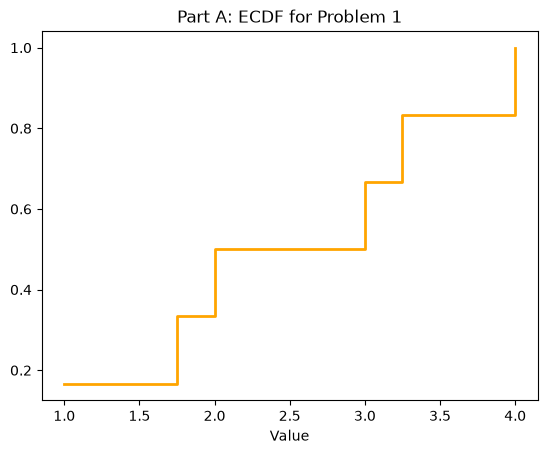

In [2]:
p1_data = np.array([1, 1.75, 2, 3, 3.25, 4])

x1, y1 = ecdf_xy(p1_data)

plt.xlabel('Value')
plt.title('Part A: ECDF for Problem 1')
plt.step(x1, y1, where='post', color='orange', lw=2)
plt.show()

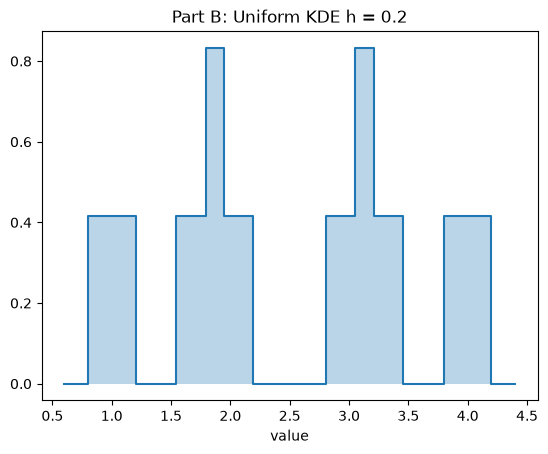

In [3]:
h = 0.2
grid = kde_grid(p1_data, h)
f_hat = uniform_kde(p1_data, grid, h)
plt.step(grid, f_hat, where='mid')
plt.fill_between(grid, f_hat, step="mid", alpha=0.3)
plt.xlabel('value')
plt.title('Part B: Uniform KDE h = 0.2')
plt.show()



In [4]:
h_silverman = silverman_bandwidth(p1_data, 'uniform')
print(f'Part C: Silverman bandwidth h = {h_silverman}')


Part C: Silverman bandwidth h = 1.2991670409500977


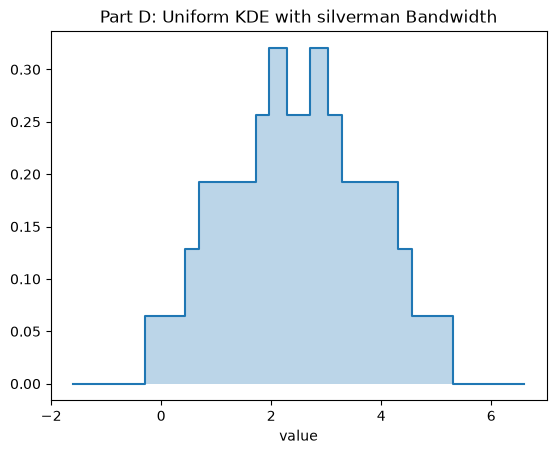

In [5]:
grid = kde_grid(p1_data, h_silverman)
f_hat = uniform_kde(p1_data, grid, h_silverman)
plt.step(grid, f_hat, where='mid')
plt.fill_between(grid, f_hat, step="mid", alpha=0.3)
plt.xlabel('value')
plt.title('Part D: Uniform KDE with silverman Bandwidth')
plt.show()

**Part E**: Part B is much more disjointed, with spikes near where the ECDF increases, whereas silverman bandwidth is more connected, almost like a bell curve. Silverman also has longer x axis

# Question 2

**Problem 2.** Suppose the data `X = [-1, -0.5, 0, 0.5, 1]` were drawn from a standard Normal distribution.

- a. Using the uniform kernel with `h = 0.6`, compute the realized KDE at `x = 0`, `f_hat_h(0)`, directly from these five numbers.
- b. Now compute `E[f_hat_h(0)]` at the same `h = 0.6`.
- c. Calculate the true density at `x=0`, using the Normal distribution.
- d. Are b and c equal? What does this mean about bias? (Keep in mind, truly proving anything about bias would require us to compare `E[f_hat_h]` to the Normal distribution for all x; calculating this at one point is only an indication of what is going on that you can extrapolate from.)
- e. Recompute `E[f_hat_h(0)]` from (b) at a much smaller bandwidth, `h = 0.1`. What happens to the gap between `E[f_hat_h(0)]` and `f(0)` as `h` shrinks?
- f. Is `f_hat_h` a consistent estimator? Explain your reasoning.
- g. What are the main considerations in choosing a bandwidth value `h`?

In [6]:
X = np.array([-1, -0.5, 0, 0.5, 1])
h = 0.6
x = 0
# To evalueate kde at zero, pass a grid with only zero
f_hat_0 = uniform_kde(X, np.array([x]), h)
print(f'part A: f_hat_0 = {f_hat_0}')


part A: f_hat_0 = [0.5]


**For part B:**
$$
E[\hat f_h(x)] = \frac{F(x+h) - F(x-h)}{2h}
$$
* Given that there is an underlying normal distibution, use its cdf to find EV.


In [7]:
h = 0.6

rng = np.random.default_rng(seed = 100)

ev = (stats.norm.cdf(x+h) - stats.norm.cdf(x-h)) / (2*h)


print(f'Part B: E[f_hat_h(0)] = {ev}')


Part B: E[f_hat_h(0)] = 0.3762448037498774


In [8]:
print(f'Part C: true f(0) = {stats.norm.pdf(0)}')

Part C: true f(0) = 0.3989422804014327


**Part D:** True f(0) does not equal f_hat_h(0). f_hat_h(0) is a biased estimator. However, in the limit as h -> 0, it will approach true f(0). 

In [9]:
h = 0.1

ev = (stats.norm.cdf(x+h) - stats.norm.cdf(x-h)) / (2*h)

print(f'Part E: E[f_hat_h(0)] = {ev}')


Part E: E[f_hat_h(0)] = 0.3982783727702899


**Part E:** New f_hat_h(0) is much closer to the true. Gap between true and estimated shrinks as h -> 0.

**Part F:** f_hat_h is consistent because when we make more draws from the normal distribution (n increases), and use a smaller h, it will approach the truth.

**Part G:** Too small of an h leads to a KDE with high variance and low bias. Too large of an h leads to a KDE with low variance and high bias. Rule of thumb is to use the silverman_bandwidth to strike a balance, but there is always a trade-off.

# Question 3

**Problem 3.** Suppose the data are `X = [5, 7, 7, 8, 10]`, and fix the bandwidth at `h = 1.5` for both kernels below.

- a. Compute the uniform-kernel KDE, `f_hat_h(x)`, at `x = 6.0`, `x = 6.5`, `x = 7.0`, `x = 8.0`, and `x = 8.5`.
- b. Compute the Gaussian-kernel KDE at the same five values of `x`, using the same `h = 1.5`.
- c. Your part (a) values should jump abruptly between some of these five points, while your part (b) values should change smoothly. Identify where the biggest jump in (a) happens, and explain in terms of the two kernel *shapes* -- not just "one is smoother" -- why that jump exists in the uniform case but not the Gaussian case.
- d. Why might you prefer one kernel over the other in practice?

In [10]:
X = np.array([5, 7, 7, 8, 10])
h = 1.5
grid = np.array([6, 6.5, 7, 8, 8.5])

f_hat_h_uniform = uniform_kde(X, grid, h)
print(f'Part A: f_hat_h_uniform = {f_hat_h_uniform}')


Part A: f_hat_h_uniform = [0.2        0.13333333 0.2        0.2        0.06666667]


In [11]:
f_hat_h_gaussian = gaussian_kde(X, grid, h)
print(f'Part B: f_hat_h_gaussian = {f_hat_h_gaussian}')

Part B: f_hat_h_gaussian = [0.15116668 0.16865731 0.17804448 0.16744524 0.15060231]


**Part C:** The largest jump in the uniform is from 0.2 when x = 8 to 0.0667 when x = 8.5. The reason that this jump is so large is it goes from having three observations at x = 8 to only one observatipn at x = 8.5. Having a hard cutoff of h = 1.5 leads to 'sharp' dropoffs. Gaussian is able to make things look 'smoother' because instead of hard cutoffs, it puts a normal distribution around every point using h to determine its width, and how they overlap builds the density. There are no harsh droppoffs because every x's contribution gradually decreases with more distance from x.

**Part D:** In practice, you might prefer the uniform KDE if you have an exact badwidth you want to consider, as in the gaussian KDE every x has the potential to contribute at every point. Conversely, you might prefer the gaussian if you want the density estimate to be continuous.

# Question 4

**Problem 4.** Load `./data/heart_failure_clinical_records_dataset.csv`.

- a. Plot a kernel density estimate of `ejection_fraction`.
- b. Use Pandas' `df.sample(frac=1.0, replace=True)` to resample the data 15 times with replacement, plotting the kernel density estimtes for each sample.
- c. For what values of `ejection_fraction` is the original plot reliable? For which values is there noticeable variation in your plots of the resampled data?

In [12]:
heart_failure = pd.read_csv('./data/heart_failure_clinical_records_dataset.csv')
heart_failure.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


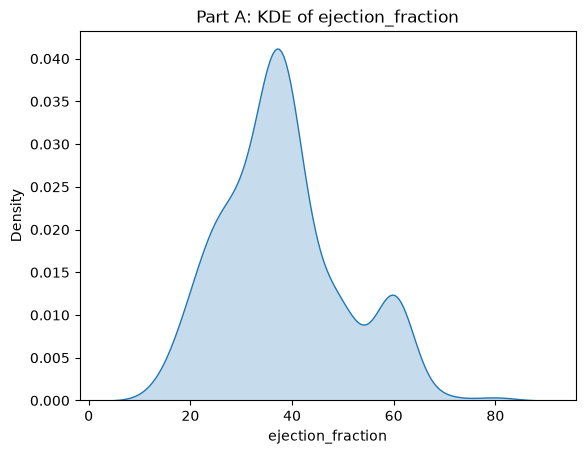

In [13]:
import seaborn as sns

sns.kdeplot(data = heart_failure['ejection_fraction'], fill=True)
plt.title('Part A: KDE of ejection_fraction')
plt.show()

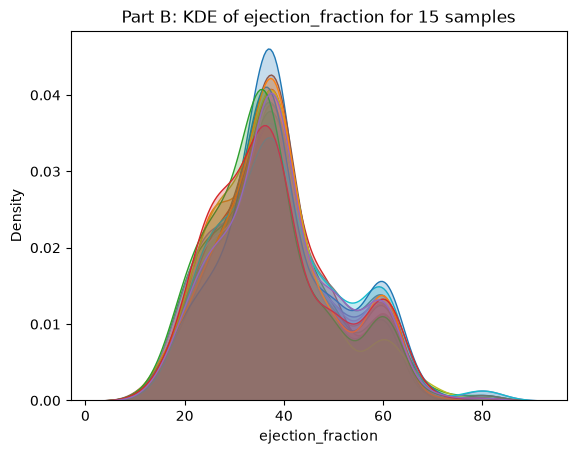

In [14]:
samples = []
num_samples = 15

for i in range(num_samples):
    samples.append(heart_failure.sample(frac=1.0, replace=True))

for sample in samples:
    sns.kdeplot(data = sample['ejection_fraction'], fill=True)
    plt.title('Part B: KDE of ejection_fraction for 15 samples')

**Part C:**

After running the resampling a few times, the original plot seems to be reliable up until about 20, 40-45, and past 70. There seems to be a lot of variability right around the 20-30 range, the peak at ~38, and from 45-70 (including the other peak at 60). 